# Análisis de la Encuesta de Competencias Financieras 2021

¿Es necesario adaptar nuestras ofertas actuales o crear nuevas en función de las tendencias nacionales en comportamiento financiero y competencias financieras?

## Librerias

In [95]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import chi2_contingency
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import kruskal
import statsmodels.formula.api as smf


## Carga del fichero csv

In [96]:
## Carga del dataset Gold

df = pd.read_csv(
    r"..\Data\Gold_ECF_090226.csv",
    sep=","
)

df.shape


(7554, 38)

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7554 entries, 0 to 7553
Data columns (total 38 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   cat_educacion          7554 non-null   object 
 1   estado_laboral         7554 non-null   object 
 2   familia                7554 non-null   object 
 3   riq_inmob              7554 non-null   object 
 4   ahorro                 7554 non-null   int64  
 5   deuda                  7554 non-null   int64  
 6   adq_ahorro2            7554 non-null   int64  
 7   adq_deuda2             7554 non-null   int64  
 8   adq_otro               7554 non-null   int64  
 9   ahorra_12m             7554 non-null   int64  
 10  consumo_ahorros        7554 non-null   int64  
 11  cred_inf               7554 non-null   int64  
 12  cred_form              7554 non-null   int64  
 13  cred_add               7554 non-null   int64  
 14  impago                 7554 non-null   int64  
 15  ayud

In [98]:
df.head()

,cat_educacion,estado_laboral,familia,riq_inmob,ahorro,deuda,adq_ahorro2,adq_deuda2,adq_otro,ahorra_12m,...,nivel_comp_fin,comp_fin_bin,prestamo_gastos,morosidad,denegacion_credito,uso_ahorros,vulnerabilidad,idx_estres_financiero,idx_uso_credito,idx_ahorro
0,Universidad,Asalariado,Vive con pareja,Solo residencia principal,0,1,0,1,1,1,...,bajo,0,0,0,0,1,1,1,2,1
1,Universidad,Asalariado,Otros adultos,Residencia principal y otras,0,1,0,0,0,0,...,bajo,0,1,0,0,0,1,1,1,0
2,Educación Secundaria,Asalariado,Vive solo,Residencia principal y otras,1,0,1,0,1,1,...,alto,1,0,0,0,0,0,0,0,3
3,Educación Secundaria,Asalariado,Vive con pareja,Solo residencia principal,1,1,0,0,0,1,...,bajo,0,0,0,0,0,0,0,1,2
4,Educación Primaria,Asalariado,Otros adultos,Solo residencia principal,0,1,0,1,1,0,...,bajo,0,1,0,0,0,1,1,3,0


In [99]:
df.columns.tolist()

['cat_educacion',
 'estado_laboral',
 'familia',
 'riq_inmob',
 'ahorro',
 'deuda',
 'adq_ahorro2',
 'adq_deuda2',
 'adq_otro',
 'ahorra_12m',
 'consumo_ahorros',
 'cred_inf',
 'cred_form',
 'cred_add',
 'impago',
 'ayudas',
 'rechazo',
 'semirechazo',
 'nopiden',
 'age',
 'ID',
 'year',
 'inflacion_ok',
 'interes_comp_ok',
 'diversificacion_ok',
 'weight',
 'edad_grupo',
 'score_comp_fin',
 'nivel_comp_fin',
 'comp_fin_bin',
 'prestamo_gastos',
 'morosidad',
 'denegacion_credito',
 'uso_ahorros',
 'vulnerabilidad',
 'idx_estres_financiero',
 'idx_uso_credito',
 'idx_ahorro']

## 1. Preparación de la base analítica

### 1.1. Agrupación estructural de variables

Se definen listas de variables para organizar el análisis en bloques homogéneos:

- **STRATA_COLS**: variables sociodemográficas utilizadas para segmentación.
- **BEHAVIOR_COLS**: variables que capturan comportamiento financiero real.
- **ALL_NEEDED**: conjunto mínimo de variables necesarias para análisis descriptivos y modelos posteriores.

Estas agrupaciones permiten mantener el código modular y reutilizable.


In [100]:
# Соц-дем (страты)
STRATA_COLS = ["cat_educacion", "estado_laboral", "familia", "riq_inmob"]

# Поведение (то, что нужно для пункта 2)
BEHAVIOR_COLS = [
    "ahorro", "deuda",
    "adq_ahorro2", "adq_deuda2", "adq_otro",
    "ahorra_12m",
    "consumo_ahorros",
    "cred_inf", "cred_form", "cred_add",
    "impago",
    "ayudas",
    "rechazo", "semirechazo", "nopiden"
]

ALL_NEEDED = ["age"] + STRATA_COLS + BEHAVIOR_COLS

# DataFrame de trabajo para análisis de comportamiento
work = df.copy()


## 2. Indicador de competencia financiera

El indicador de competencia financiera se construye a partir de tres preguntas estándar sobre:

- Inflación
- Interés compuesto
- Diversificación del riesgo

Cada respuesta correcta suma un punto, generando una puntuación total entre 0 y 3.

A partir de esta puntuación se derivan:

- Un indicador categórico (bajo, medio, alto).
- Un indicador binario (`comp_fin_bin`), donde:
  - 1 = competente (score ≥ 2)
  - 0 = no competente (score ≤ 1)

Este indicador permite analizar la relación entre conocimiento financiero, comportamiento real y vulnerabilidad.


### 2.1 Distribución del nivel de competencia


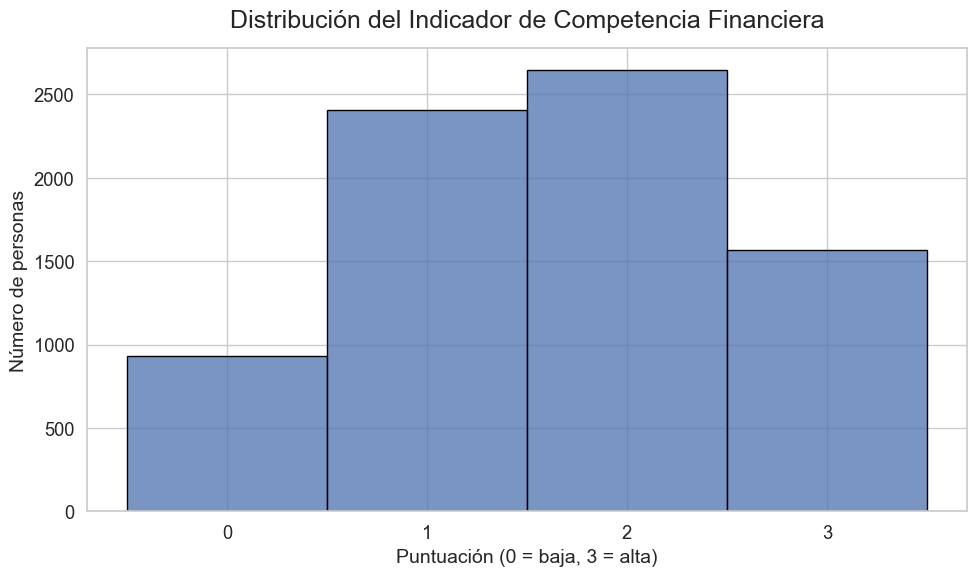

In [101]:
# Estilo general
sns.set(style="whitegrid", palette="deep", font_scale=1.2)

plt.figure(figsize=(10,6))

# Histograma
sns.histplot(
    data=df,
    x="score_comp_fin",
    bins=[-0.5, 0.5, 1.5, 2.5, 3.5],  # para separar bien 0,1,2,3
    color="#4C72B0",
    kde=False,
    edgecolor="black"
)

# Títulos y etiquetas
plt.title("Distribución del Indicador de Competencia Financiera", fontsize=18, pad=15)
plt.xlabel("Puntuación (0 = baja, 3 = alta)", fontsize=14)
plt.ylabel("Número de personas", fontsize=14)

# Ajustes finales
plt.xticks([0,1,2,3])
plt.tight_layout()
plt.show()

C:\Users\edo\AppData\Local\Temp\ipykernel_17312\1028436493.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


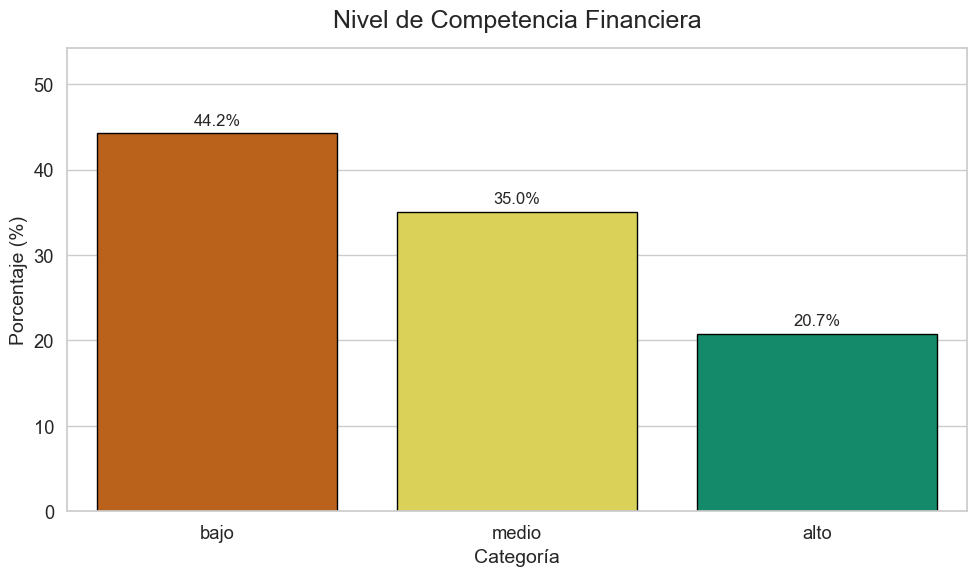

In [102]:

sns.set(style="whitegrid", font_scale=1.2)

# Orden lógico
orden = ["bajo", "medio", "alto"]

# Calcular porcentajes
porc = (
    df["nivel_comp_fin"]
    .value_counts(normalize=True)
    .reindex(orden)
    * 100
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=porc.index,
    y=porc.values,
    palette=["#D55E00", "#F0E442", "#009E73"],  # rojo → amarillo → verde
    edgecolor="black"
)

plt.title("Nivel de Competencia Financiera", fontsize=18, pad=15)
plt.xlabel("Categoría", fontsize=14)
plt.ylabel("Porcentaje (%)", fontsize=14)

# Etiquetas encima de cada barra
for i, v in enumerate(porc.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=12)

plt.ylim(0, porc.max() + 10)
plt.tight_layout()
plt.show()

C:\Users\edo\AppData\Local\Temp\ipykernel_17312\2705371866.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


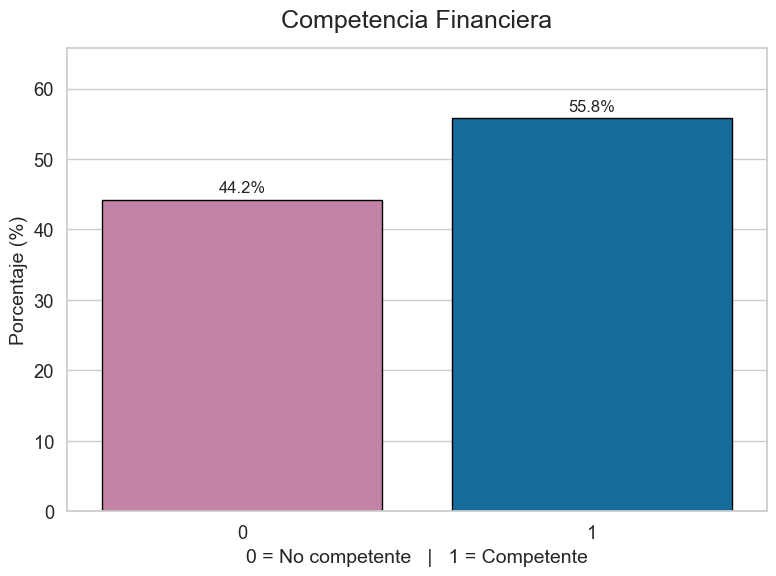

In [103]:
plt.figure(figsize=(8,6))

# Calcular porcentajes
porc_bin = (
    df["comp_fin_bin"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

sns.barplot(
    x=porc_bin.index,
    y=porc_bin.values,
    palette=["#CC79A7", "#0072B2"],  # dos colores contrastados
    edgecolor="black"
)

plt.title("Competencia Financiera", fontsize=18, pad=15)
plt.xlabel("0 = No competente   |   1 = Competente", fontsize=14)
plt.ylabel("Porcentaje (%)", fontsize=14)

# Etiquetas encima de cada barra
for i, v in enumerate(porc_bin.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=12)

plt.ylim(0, porc_bin.max() + 10)
plt.tight_layout()
plt.show()

### 2.2 Competencia financiera por variables sociodemográficas

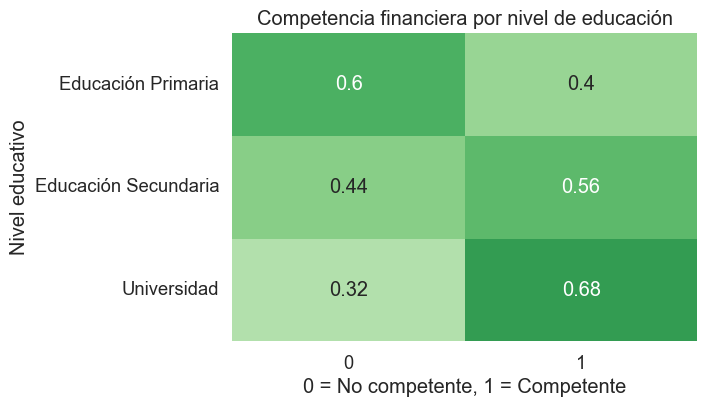

In [104]:
tabla_edu_comp = pd.crosstab(
    df["cat_educacion"],
    df["comp_fin_bin"],
    normalize="index"
)

plt.figure(figsize=(6,4))
sns.heatmap(
    tabla_edu_comp,
    annot=True,
    cmap="Greens",
    vmin=0,
    vmax=1,
    cbar=False
)

plt.title("Competencia financiera por nivel de educación")
plt.xlabel("0 = No competente, 1 = Competente")
plt.ylabel("Nivel educativo")

plt.show()

In [105]:
comp_edu_pond = pd.crosstab(
    df["cat_educacion"],
    df["comp_fin_bin"],
    values=df["weight"],
    aggfunc="sum",
    normalize="index"
).round(2)

comp_edu_pond

comp_fin_bin,0,1
cat_educacion,,
Educación Primaria,0.61,0.39
Educación Secundaria,0.44,0.56
Universidad,0.32,0.68


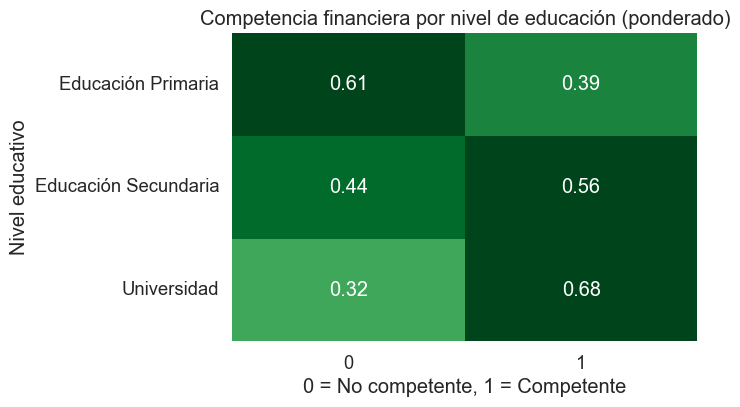

In [106]:
plt.figure(figsize=(6,4))
sns.heatmap(
    comp_edu_pond,
    annot=True,
    cmap="Greens",
    vmin=0,
    vmax=0.5,
    cbar=False
)

plt.title("Competencia financiera por nivel de educación (ponderado)")
plt.xlabel("0 = No competente, 1 = Competente")
plt.ylabel("Nivel educativo")

plt.show()

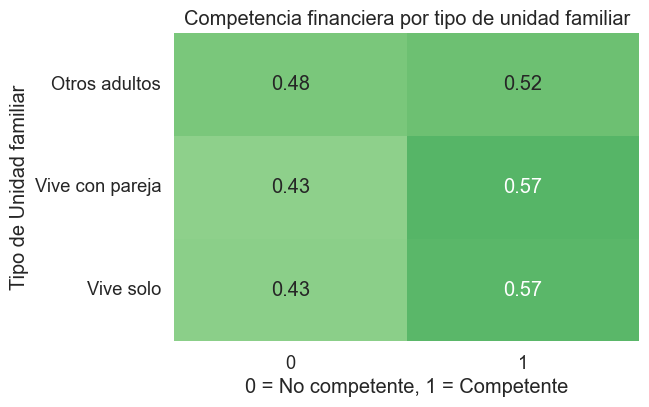

In [107]:
tabla_fam_comp = pd.crosstab(
    df["familia"],
    df["comp_fin_bin"],
    normalize="index"
)

plt.figure(figsize=(6,4))
ax = sns.heatmap(
    tabla_fam_comp,
    annot=True,
    cmap="Greens",
    vmin=0,
    vmax=1,
    cbar=False
)

plt.title("Competencia financiera por tipo de unidad familiar")
plt.xlabel("0 = No competente, 1 = Competente")
plt.ylabel("Tipo de Unidad familiar")

# Rotar etiquetas del eje Y para que se lean horizontalmente
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.show()

In [108]:
comp_fam_pond = pd.crosstab(
    df["familia"],
    df["comp_fin_bin"],
    values=df["weight"],
    aggfunc="sum",
    normalize="index"
).round(2)

comp_fam_pond

comp_fin_bin,0,1
familia,,
Otros adultos,0.50,0.50
Vive con pareja,0.46,0.54
Vive solo,0.46,0.54


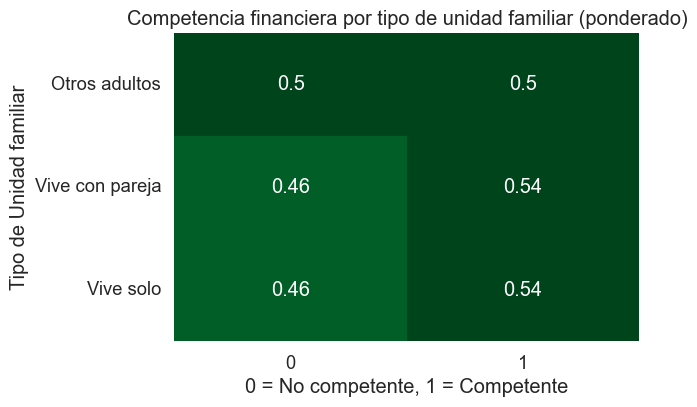

In [109]:
plt.figure(figsize=(6,4))
sns.heatmap(
    comp_fam_pond,
    annot=True,
    cmap="Greens",
    vmin=0,
    vmax=0.5,
    cbar=False
)

plt.title("Competencia financiera por tipo de unidad familiar (ponderado)")
plt.xlabel("0 = No competente, 1 = Competente")
plt.ylabel("Tipo de Unidad familiar")

plt.show()

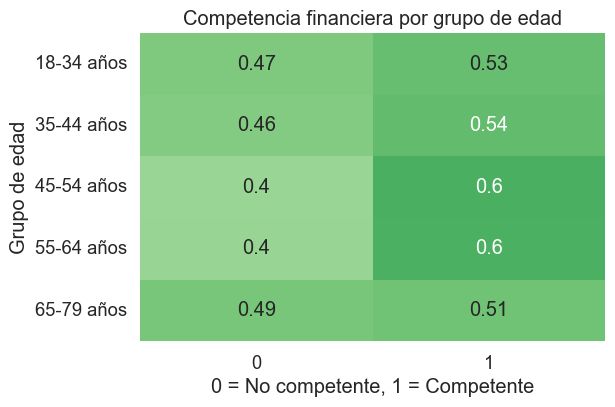

In [110]:
tabla_edad_comp = pd.crosstab(
    work["edad_grupo"],
    df["comp_fin_bin"],
    normalize="index"
)

plt.figure(figsize=(6,4))
ax = sns.heatmap(
    tabla_edad_comp,
    annot=True,
    cmap="Greens",
    vmin=0,
    vmax=1,
    cbar=False
)

plt.title("Competencia financiera por grupo de edad")
plt.xlabel("0 = No competente, 1 = Competente")
plt.ylabel("Grupo de edad")

# Forzar etiquetas horizontales en el eje Y
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha="right")

plt.show()


In [111]:
comp_edad_pond = pd.crosstab(
    work["edad_grupo"],
    df["comp_fin_bin"],
    values=df["weight"],
    aggfunc="sum",
    normalize="index"
).round(2)

comp_edad_pond

comp_fin_bin,0,1
edad_grupo,,
18-34 años,0.49,0.51
35-44 años,0.48,0.52
45-54 años,0.42,0.58
55-64 años,0.42,0.58
65-79 años,0.54,0.46


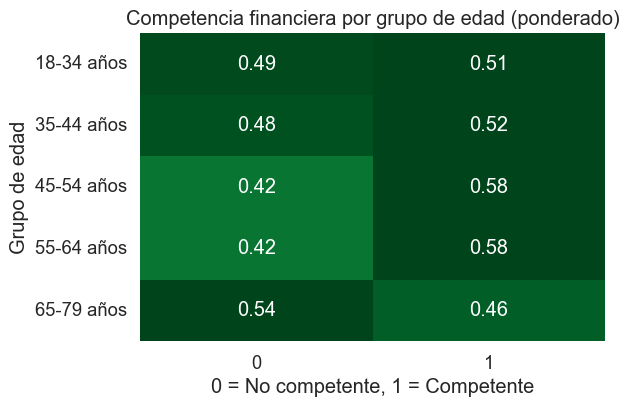

In [112]:
plt.figure(figsize=(6,4))
sns.heatmap(
    comp_edad_pond,
    annot=True,
    cmap="Greens",
    vmin=0,
    vmax=0.5,
    cbar=False
)

plt.title("Competencia financiera por grupo de edad (ponderado)")
plt.xlabel("0 = No competente, 1 = Competente")
plt.ylabel("Grupo de edad")

plt.show()

C:\Users\edo\AppData\Local\Temp\ipykernel_17312\3415512844.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["weight"].sum())


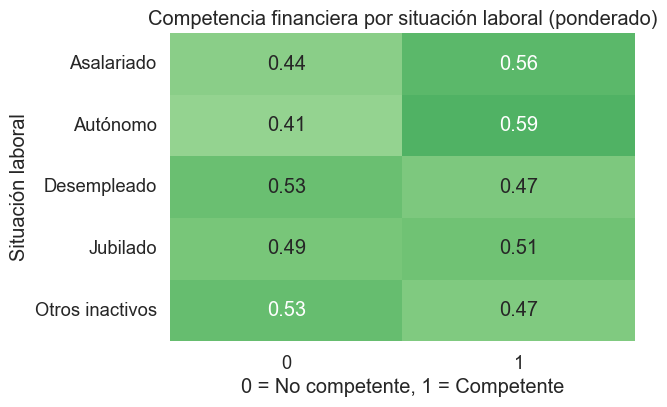

In [113]:
comp_lab_pond = (
    df
    .groupby(["estado_laboral", "comp_fin_bin"])
    .apply(lambda x: x["weight"].sum())
    .unstack(fill_value=0)
)

comp_lab_pond = comp_lab_pond.div(comp_lab_pond.sum(axis=1), axis=0)

plt.figure(figsize=(6,4))
sns.heatmap(
    comp_lab_pond,
    annot=True,
    cmap="Greens",
    vmin=0,
    vmax=1,
    cbar=False
)

plt.title("Competencia financiera por situación laboral (ponderado)")
plt.xlabel("0 = No competente, 1 = Competente")
plt.ylabel("Situación laboral")

plt.show()


C:\Users\edo\AppData\Local\Temp\ipykernel_17312\2045784005.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["weight"].sum())


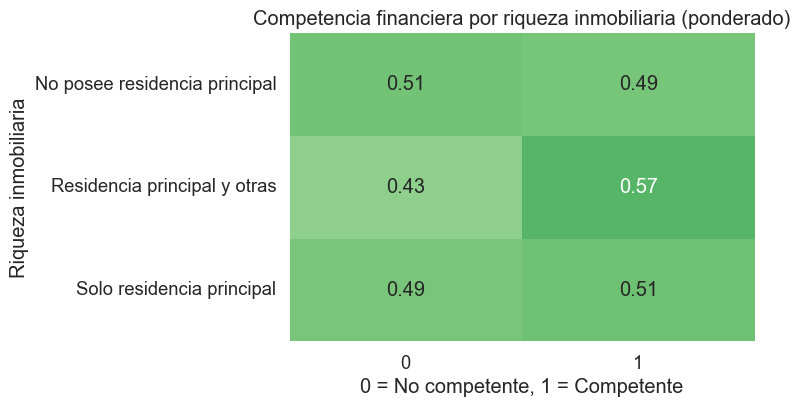

In [114]:
comp_riq_pond = (
    df
    .groupby(["riq_inmob", "comp_fin_bin"])
    .apply(lambda x: x["weight"].sum())
    .unstack(fill_value=0)
)

comp_riq_pond = comp_riq_pond.div(comp_riq_pond.sum(axis=1), axis=0)

plt.figure(figsize=(6,4))
sns.heatmap(
    comp_riq_pond,
    annot=True,
    cmap="Greens",
    vmin=0,
    vmax=1,
    cbar=False
)

plt.title("Competencia financiera por riqueza inmobiliaria (ponderado)")
plt.xlabel("0 = No competente, 1 = Competente")
plt.ylabel("Riqueza inmobiliaria")

plt.show()


### 2.3. Tests Estadísticos en la variable Competencia financiera

#### 2.3.1. Chi cuadrado de indendencia + Cramer's V

In [115]:


# Variables a analizar contra competencia (target)
VARIABLES = [
    "cat_educacion",
    "familia",
    "estado_laboral",
    "riq_inmob",
    "edad_grupo"
]

TARGET = "comp_fin_bin"

def test_competencia(df, work, target, variables):
    resultados = []

    # === BLOQUE 1: construir dataframe temporal ===
    temp = pd.DataFrame()
    temp[target] = df[target]

    for var in variables:
        if var in df.columns:
            temp[var] = df[var]
        elif var in work.columns:
            temp[var] = work[var]
        else:
            continue

    # === BLOQUE 2: análisis ===
    for var in variables:
        if var not in temp.columns:
            continue

        print("\n------------------------------")
        print(f"Test Chi-cuadrado: {target} vs {var}")
        print("------------------------------")

        tabla = pd.crosstab(temp[var], temp[target])
        print("\nTabla de contingencia:")
        print(tabla)

        if tabla.shape[0] < 2 or tabla.shape[1] < 2:
            print("No se puede hacer chi-cuadrado: tabla incompleta")
            resultados.append((var, None, None))
            continue

        chi2, p, dof, expected = chi2_contingency(tabla)

        print(f"\nChi2 = {chi2:.3f}")
        print(f"p-valor = {p:.5f}")
        print(f"Grados de libertad = {dof}")

        if p < 0.05:
            print("Asociación SIGNIFICATIVA (p < 0.05)")
        else:
            print("Asociación NO significativa (p ≥ 0.05)")

        # Cálculo de Cramer's V
        n = tabla.sum().sum()
        r, k = tabla.shape
        cramers_v = np.sqrt(chi2 / (n * (min(r - 1, k - 1))))

        resultados.append((var, p, cramers_v))

    # === BLOQUE 3: resumen final de resultados ===
    print("\n\nResumen final de p-valores:")
    resumen = pd.DataFrame(resultados, columns=["Variable", "p_valor", "Cramers_V"])

    # Añadir columna de significancia
    resumen["Significancia"] = resumen["p_valor"].apply(
        lambda p: "Significativa" if p is not None and p < 0.05 else
                  ("No significativa" if p is not None else "No evaluable")
    )

    print(resumen)
    return resumen


# Ejecutar análisis
resultados = test_competencia(df, work, TARGET, VARIABLES)


------------------------------
Test Chi-cuadrado: comp_fin_bin vs cat_educacion
------------------------------

Tabla de contingencia:
comp_fin_bin             0     1
cat_educacion                   
Educación Primaria    1505  1009
Educación Secundaria   836  1048
Universidad           1001  2155

Chi2 = 449.440
p-valor = 0.00000
Grados de libertad = 2
Asociación SIGNIFICATIVA (p < 0.05)

------------------------------
Test Chi-cuadrado: comp_fin_bin vs familia
------------------------------

Tabla de contingencia:
comp_fin_bin        0     1
familia                    
Otros adultos     862   925
Vive con pareja  2065  2747
Vive solo         415   540

Chi2 = 15.245
p-valor = 0.00049
Grados de libertad = 2
Asociación SIGNIFICATIVA (p < 0.05)

------------------------------
Test Chi-cuadrado: comp_fin_bin vs estado_laboral
------------------------------

Tabla de contingencia:
comp_fin_bin        0     1
estado_laboral             
Asalariado       1539  2194
Autónomo          335  

##### Conclusiones de Chi cuadrado y Cramer's V
- La competencia financiera está asociada de forma significativa con todas las variables analizadas.
- La educación es el factor más determinante, con la asociación más fuerte y el mayor tamaño del efecto.
- La situación laboral también influye, aunque con un efecto más moderado.
- La edad, la estructura familiar y la riqueza inmobiliaria muestran asociaciones significativas pero de baja intensidad.
- En conjunto, los resultados indican que la competencia financiera no se distribuye de manera uniforme en la población y está condicionada principalmente por el nivel educativo y, en menor medida, por la situación laboral.


#### 2.3.2. Regresión logística

In [116]:
VARIABLES = [
    "cat_educacion",
    "familia",
    "estado_laboral",
    "riq_inmob",
    "edad_grupo"
]

TARGET = "comp_fin_bin"

def regresion_logistica(df, work, target, variables):

    # === 1. Construir dataframe temporal ===
    temp = pd.DataFrame()
    temp[target] = df[target]

    for var in variables:
        if var in df.columns:
            temp[var] = df[var]
        elif var in work.columns:
            temp[var] = work[var]

    # Eliminar filas con NA
    temp = temp.dropna()

    # === 2. Crear dummies ===
    X = pd.get_dummies(temp[variables], drop_first=True)
    y = temp[target]

    # === 3. Convertir TODO a float ===
    X = X.astype(float)
    y = y.astype(float)

    # Alinear índices 
    X, y = X.align(y, join="inner", axis=0)

    # Añadir constante
    X = sm.add_constant(X)

    # === 4. Ajustar modelo logístico ===
    modelo = sm.Logit(y, X).fit()

    # === 5. Odds ratios e intervalos ===
    params = modelo.params
    conf = modelo.conf_int()
    conf.columns = ["2.5%", "97.5%"]

    odds = np.exp(params)
    conf_odds = np.exp(conf)

    resultados = pd.DataFrame({
        "Variable": params.index,
        "Coeficiente": params.values,
        "Odds_Ratio": odds,
        "IC_2.5%": conf_odds["2.5%"],
        "IC_97.5%": conf_odds["97.5%"],
        "p_valor": modelo.pvalues
    })

    print(modelo.summary())
    print("\n\nResultados interpretables (Odds Ratios):")
    print(resultados)

    return resultados


# Ejecutar análisis
resultados_logit = regresion_logistica(df, work, TARGET, VARIABLES)
print(resultados)


Optimization terminated successfully.
         Current function value: 0.648376
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:           comp_fin_bin   No. Observations:                 7554
Model:                          Logit   Df Residuals:                     7539
Method:                           MLE   Df Model:                           14
Date:                Sat, 14 Feb 2026   Pseudo R-squ.:                 0.05553
Time:                        11:03:45   Log-Likelihood:                -4897.8
converged:                       True   LL-Null:                       -5185.8
Covariance Type:            nonrobust   LLR p-value:                6.845e-114
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
const                                     -0.8267   

##### Conclusiones de la Regresión logística
- La educación es el factor más importante: incluso controlando por edad, empleo, familia y riqueza, sigue siendo el predictor más fuerte de la competencia financiera.
- La situación laboral también influye, aunque con un efecto más moderado.
- Edad, estructura familiar y riqueza inmobiliaria mantienen asociaciones significativas, pero con impacto pequeño cuando se ajustan por el resto.
- En conjunto, el modelo confirma que la competencia financiera está fuertemente condicionada por el nivel educativo, y en segundo lugar por la inserción laboral.


##### Conclusiones reales de la Regresión logística
# CHECK

- **Educación** es el factor más determinante:  
  - Secundaria → OR = 2.05 (p < 0.001)  
  - Universidad → OR = 3.31 (p < 0.001)  
  ✔ Confirma que es el predictor más fuerte.

- **Riqueza inmobiliaria** (Residencia principal y otras) también es significativa:  
  - OR = 1.37 (p < 0.001)

- **Edad** solo es significativa en:
  - 45–54 años → OR = 1.35 (p < 0.001)  
  - 55–64 años → OR = 1.48 (p < 0.001)

- **Situación laboral** → no significativa (p > 0.05).  
- **Estructura familiar** → no significativa (p > 0.05).

**Resumen:**  
La competencia financiera está explicada principalmente por el nivel educativo, seguida por riqueza inmobiliaria y algunos tramos de edad. No hay evidencia robusta de efecto independiente de la situación laboral ni de la estructura familiar.


#### 2.5.3. Testear contra comportamiento financiero

In [117]:


INDICES = [
    "idx_estres_financiero",
    "idx_uso_credito",
    "idx_ahorro"
]

CONTROL_VARS = "C(estado_laboral) + C(edad_grupo) + C(cat_educacion) + C(riq_inmob) + C(familia)"

resultados = []

for var in INDICES:
    
    formula = f"{var} ~ comp_fin_bin + {CONTROL_VARS}"
    
    modelo = smf.wls(
        formula,
        data=df,
        weights=df["weight"]
    ).fit(cov_type="HC3")
    
    coef = modelo.params["comp_fin_bin"]
    pval = modelo.pvalues["comp_fin_bin"]
    
    resultados.append({
        "Indice": var,
        "Coef_beta": coef,
        "p_value": pval,
        "R2": modelo.rsquared
    })

resultados_indices = pd.DataFrame(resultados)
resultados_indices


,Indice,Coef_beta,p_value,R2
0,idx_estres_financiero,0.019548,3.039468e-01,0.052261
1,idx_uso_credito,0.056172,1.575563e-02,0.131177
2,idx_ahorro,0.255572,4.774334e-24,0.213970


##### Conclusiones de la relación entre competencia financiera y comportamiento financiero (índices)

- La competencia financiera no muestra una asociación estadísticamente significativa con el índice de estrés financiero (p = 0.30). 
  Esto indica que, una vez controlados los factores socioeconómicos, la competencia no reduce de forma estructural el nivel agregado de estrés financiero.

- En el índice de uso de crédito, la competencia presenta un efecto positivo y significativo (p < 0.05), aunque de magnitud moderada. 
  Esto sugiere que las personas competentes utilizan más instrumentos de crédito, probablemente dentro del sistema formal.

- El efecto más fuerte se observa en el índice de ahorro (β = 0.256, p < 0.001), donde la competencia financiera incrementa de manera clara el comportamiento orientado al ahorro.

- En conjunto, los resultados indican que la competencia financiera impacta principalmente en comportamientos activos y planificados (especialmente el ahorro), pero no logra reducir significativamente el estrés financiero agregado.

- Esto refuerza la idea de que el estrés financiero responde más a factores estructurales (empleo, riqueza, educación) que exclusivamente a habilidades financieras.


### 3 Indicadores compuestos de comportamiento real estress, uso de crédito y ahorro

Se construyen tres índices sintéticos que capturan comportamiento financiero observable:

- **Índice de estrés financiero (`idx_estres_financiero`)**  
  Suma de indicadores de tensión económica: uso de ahorros para gastos, uso de crédito (formal o informal), impago y recepción de ayudas.  
  Valores más altos indican mayor vulnerabilidad financiera.

- **Índice de uso de crédito (`idx_uso_credito`)**  
  Suma de variables relacionadas con deuda y adquisición de productos crediticios.  
  Valores más altos reflejan mayor utilización de instrumentos de crédito.

- **Índice de ahorro (`idx_ahorro`)**  
  Suma de comportamientos vinculados al ahorro y acumulación financiera.  
  Valores más altos indican mayor orientación al ahorro.


### 3.1. Comportamientos financieros por grupo de edad

In [118]:
behavior_by_age = (
    work
    .groupby("edad_grupo", dropna=False)[[c for c in BEHAVIOR_COLS if c in work.columns]]
    .mean()
    .mul(100)
    .round(1)
)
behavior_by_age["N"] = work.groupby("edad_grupo", dropna=False).size()
behavior_by_age = behavior_by_age.reset_index()

behavior_by_age

,edad_grupo,ahorro,deuda,adq_ahorro2,adq_deuda2,adq_otro,ahorra_12m,consumo_ahorros,cred_inf,cred_form,cred_add,impago,ayudas,rechazo,semirechazo,nopiden,N
0,18-34 años,30.0,22.5,24.3,18.4,51.8,88.5,13.1,8.0,3.0,2.3,2.8,0.3,3.9,2.1,2.7,1867
1,35-44 años,44.8,63.3,23.6,29.3,59.0,79.2,12.3,8.1,3.5,1.4,3.3,0.3,3.0,1.9,2.2,1401
2,45-54 años,50.5,60.6,22.4,23.9,53.1,72.3,14.3,7.8,3.5,1.9,2.8,1.1,3.8,1.7,2.9,1712
3,55-64 años,53.2,40.2,20.5,16.7,43.8,63.5,13.9,6.0,3.4,1.8,2.7,0.5,3.0,1.4,1.9,1427
4,65-79 años,44.6,22.3,15.4,8.5,28.8,55.0,12.0,3.7,1.9,1.7,1.7,0.5,1.0,0.4,1.0,1147


### 3.2. Comportamientos financieros por edad y nivel educativo


In [119]:
if "cat_educacion" in work.columns:
    behavior_by_age_educ = (
        work
        .groupby(["edad_grupo", "cat_educacion"], dropna=False)[[c for c in BEHAVIOR_COLS if c in work.columns]]
        .mean()
        .mul(100)
        .round(1)
    )
    behavior_by_age_educ["N"] = work.groupby(["edad_grupo", "cat_educacion"], dropna=False).size()
    behavior_by_age_educ = behavior_by_age_educ.reset_index()
    display(behavior_by_age_educ)

,edad_grupo,cat_educacion,ahorro,deuda,adq_ahorro2,adq_deuda2,adq_otro,ahorra_12m,consumo_ahorros,cred_inf,cred_form,cred_add,impago,ayudas,rechazo,semirechazo,nopiden,N
0,18-34 años,Educación Primaria,17.9,26.5,18.2,19.9,46.4,77.1,21.4,16.4,4.8,3.6,6.0,0.6,6.2,2.1,6.2,336
1,18-34 años,Educación Secundaria,26.5,16.3,20.7,14.4,47.2,90.1,11.0,7.6,2.9,2.9,2.6,0.4,4.4,2.6,2.4,699
2,18-34 años,Universidad,37.9,26.1,29.8,21.0,57.9,91.8,11.5,4.9,2.4,1.3,1.7,0.1,2.4,1.7,1.4,832
3,35-44 años,Educación Primaria,24.9,57.5,11.6,25.4,47.4,66.2,13.6,13.6,4.0,1.2,7.8,0.9,5.2,2.6,5.5,346
4,35-44 años,Educación Secundaria,39.0,63.2,18.2,33.3,57.2,74.8,16.4,10.4,5.0,2.8,3.1,0.0,4.7,3.5,2.5,318
5,35-44 años,Universidad,56.6,66.1,31.5,29.3,65.3,87.2,9.9,4.6,2.6,0.8,1.2,0.1,1.2,0.8,0.5,737
6,45-54 años,Educación Primaria,28.1,55.7,8.6,23.7,41.4,58.3,16.2,12.4,4.0,1.4,5.1,1.9,6.6,3.3,5.1,573
7,45-54 años,Educación Secundaria,49.3,63.5,17.7,28.4,53.9,71.3,16.5,11.0,5.2,2.9,2.6,0.9,3.5,0.9,2.3,345
8,45-54 años,Universidad,67.1,62.8,34.5,22.0,61.2,82.9,11.8,3.1,2.4,1.9,1.3,0.5,1.9,0.9,1.6,794
9,55-64 años,Educación Primaria,32.4,35.1,9.4,14.0,31.5,48.3,15.3,9.3,3.1,1.8,3.6,0.7,3.6,1.6,2.6,615


### 3.3. Visualizaciones

In [120]:

composite_by_age = (
    work
    .groupby("edad_grupo", dropna=False)[["idx_estres_financiero", "idx_uso_credito", "idx_ahorro"]]
    .mean()
    .round(2)
)
composite_by_age["N"] = work.groupby("edad_grupo", dropna=False).size()
composite_by_age = composite_by_age.reset_index()

display(composite_by_age)


,edad_grupo,idx_estres_financiero,idx_uso_credito,idx_ahorro,N
0,18-34 años,0.30,0.46,1.43,1867
1,35-44 años,0.29,0.97,1.48,1401
2,45-54 años,0.31,0.90,1.45,1712
3,55-64 años,0.28,0.62,1.37,1427
4,65-79 años,0.22,0.34,1.15,1147


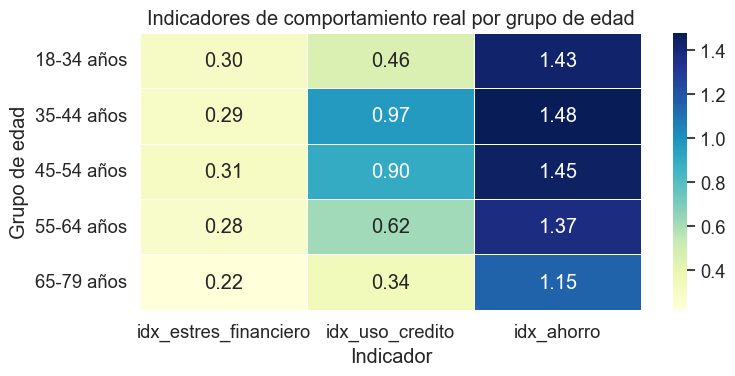

In [121]:

# убираем N из визуализации
heatmap_data = composite_by_age.set_index("edad_grupo")[[
    "idx_estres_financiero",
    "idx_uso_credito",
    "idx_ahorro"
]]

plt.figure(figsize=(8, 4))

sns.heatmap(
    heatmap_data,
    annot=True,        # показывать числа
    fmt=".2f",
    cmap="YlGnBu",     # палитра
    linewidths=0.5
)

plt.title("Indicadores de comportamiento real por grupo de edad")
plt.ylabel("Grupo de edad")
plt.xlabel("Indicador")

plt.tight_layout()
plt.show()


In [122]:
def make_pivot_index(df, group_col):
    """
    Строит сводную таблицу:
    group_col vs поведенческие индексы
    """

    tab = (
        df
        .groupby(group_col)[
            ["idx_estres_financiero",
             "idx_uso_credito",
             "idx_ahorro"]
        ]
        .mean()
        .round(2)
    )

    # Добавим размер группы
    tab["N"] = df.groupby(group_col).size()

    return tab.reset_index()


In [123]:
pivot_educ = make_pivot_index(work, "cat_educacion")
display(pivot_educ)


,cat_educacion,idx_estres_financiero,idx_uso_credito,idx_ahorro,N
0,Educación Primaria,0.37,0.60,0.93,2514
1,Educación Secundaria,0.31,0.65,1.37,1884
2,Universidad,0.20,0.74,1.77,3156


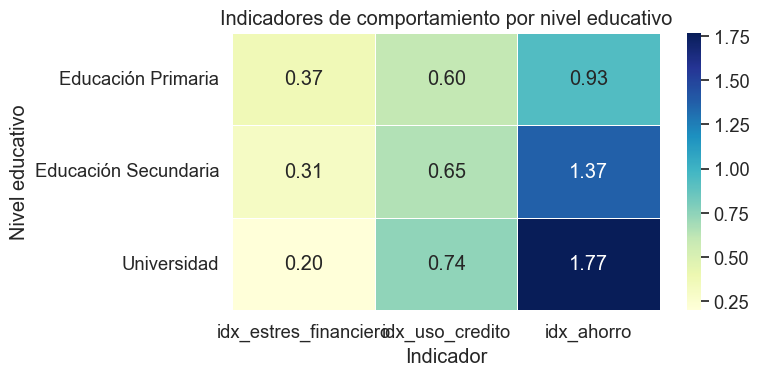

In [124]:
heat_data = pivot_educ.set_index("cat_educacion")[
    ["idx_estres_financiero", "idx_uso_credito", "idx_ahorro"]
]

plt.figure(figsize=(8, 4))

sns.heatmap(
    heat_data,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Indicadores de comportamiento por nivel educativo")
plt.ylabel("Nivel educativo")
plt.xlabel("Indicador")
plt.tight_layout()
plt.show()


In [125]:
pivot_laboral = make_pivot_index(work, "estado_laboral")
display(pivot_laboral)


,estado_laboral,idx_estres_financiero,idx_uso_credito,idx_ahorro,N
0,Asalariado,0.26,0.86,1.57,3733
1,Autónomo,0.28,0.83,1.59,844
2,Desempleado,0.49,0.47,0.99,780
3,Jubilado,0.20,0.39,1.20,1060
4,Otros inactivos,0.30,0.32,1.10,1137


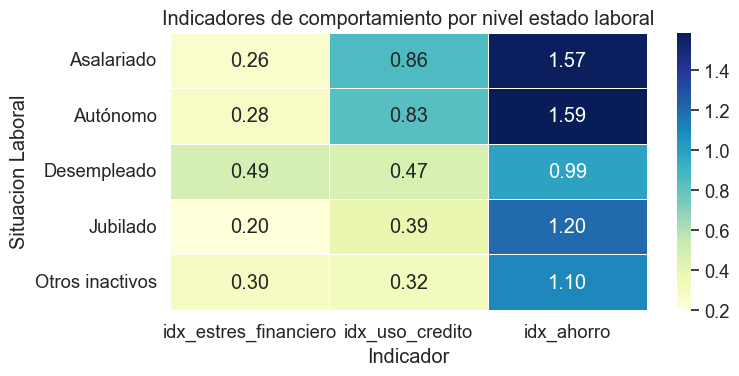

In [126]:
heat_data = pivot_laboral.set_index("estado_laboral")[
    ["idx_estres_financiero", "idx_uso_credito", "idx_ahorro"]
]

plt.figure(figsize=(8, 4))

sns.heatmap(
    heat_data,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Indicadores de comportamiento por nivel estado laboral")
plt.ylabel("Situacion Laboral")
plt.xlabel("Indicador")
plt.tight_layout()
plt.show()


In [127]:
pivot_familia = make_pivot_index(work, "familia")
display(pivot_familia)


,familia,idx_estres_financiero,idx_uso_credito,idx_ahorro,N
0,Otros adultos,0.28,0.37,1.26,1787
1,Vive con pareja,0.28,0.79,1.43,4812
2,Vive solo,0.31,0.63,1.43,955


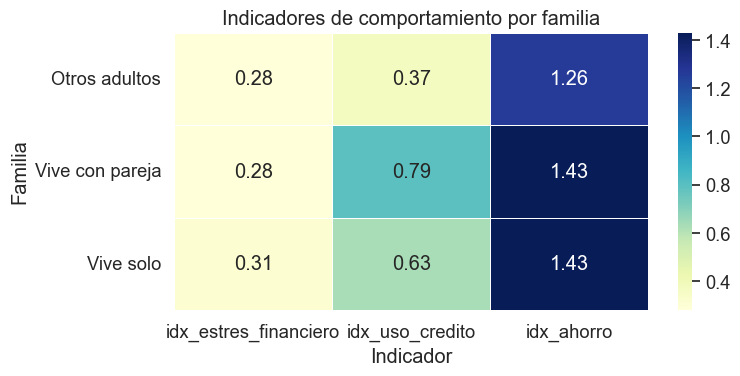

In [128]:
heat_data = pivot_familia.set_index("familia")[
    ["idx_estres_financiero", "idx_uso_credito", "idx_ahorro"]
]

plt.figure(figsize=(8, 4))

sns.heatmap(
    heat_data,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Indicadores de comportamiento por familia")
plt.ylabel("Familia")
plt.xlabel("Indicador")
plt.tight_layout()
plt.show()


In [129]:
pivot_inmob = make_pivot_index(work, "riq_inmob")
display(pivot_inmob)


,riq_inmob,idx_estres_financiero,idx_uso_credito,idx_ahorro,N
0,No posee residencia principal,0.45,0.59,1.21,1748
1,Residencia principal y otras,0.20,0.62,1.61,2847
2,Solo residencia principal,0.27,0.76,1.29,2959


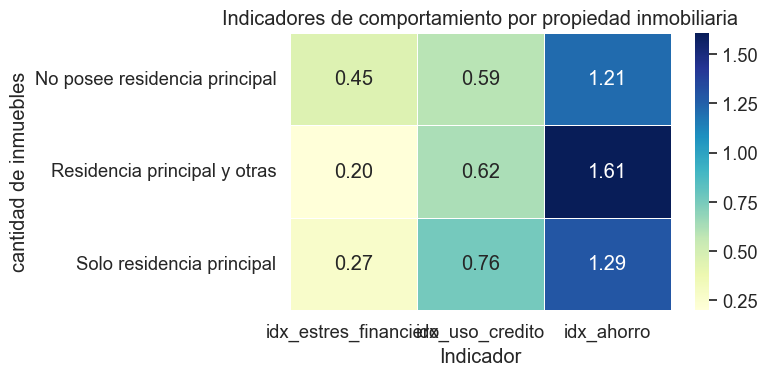

In [130]:
heat_data = pivot_inmob.set_index("riq_inmob")[
    ["idx_estres_financiero", "idx_uso_credito", "idx_ahorro"]
]

plt.figure(figsize=(8, 4))

sns.heatmap(
    heat_data,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Indicadores de comportamiento por propiedad inmobiliaria")
plt.ylabel("cantidad de inmuebles")
plt.xlabel("Indicador")
plt.tight_layout()
plt.show()

### 3.4. Ponderación de índices

In [131]:
def weighted_mean(series, weights):
    return (series * weights).sum() / weights.sum()


def make_weighted_pivot(df, group_col, weight_col):

    result = []

    for group_value, group_df in df.groupby(group_col):

        weights = group_df[weight_col]

        row = {
            group_col: group_value,
            "idx_estres_financiero": weighted_mean(group_df["idx_estres_financiero"], weights),
            "idx_uso_credito": weighted_mean(group_df["idx_uso_credito"], weights),
            "idx_ahorro": weighted_mean(group_df["idx_ahorro"], weights),
            "N_muestral": len(group_df),
            "N_ponderado": weights.sum()
        }

        result.append(row)

    return pd.DataFrame(result).round(3)


In [132]:
pivot_educ_w = make_weighted_pivot(work, "cat_educacion", "weight")
display(pivot_educ_w)

,cat_educacion,idx_estres_financiero,idx_uso_credito,idx_ahorro,N_muestral,N_ponderado
0,Educación Primaria,0.390,0.594,0.901,2514,1.474152e+07
1,Educación Secundaria,0.334,0.676,1.360,1884,8.228664e+06
2,Universidad,0.219,0.750,1.760,3156,1.207886e+07


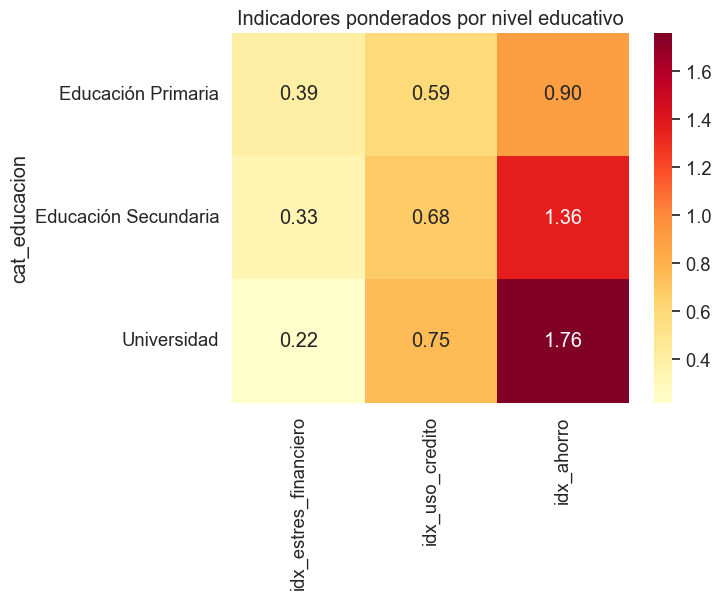

In [133]:
heat_data = pivot_educ_w.set_index("cat_educacion")[
    ["idx_estres_financiero", "idx_uso_credito", "idx_ahorro"]
]

sns.heatmap(
    heat_data,
    annot=True,
    cmap="YlOrRd",
    fmt=".2f"
)

plt.title("Indicadores ponderados por nivel educativo")
plt.show()

In [134]:
pivot_laboral_w = make_weighted_pivot(work, "estado_laboral", "weight")
display(pivot_laboral_w)

,estado_laboral,idx_estres_financiero,idx_uso_credito,idx_ahorro,N_muestral,N_ponderado
0,Asalariado,0.299,0.877,1.496,3733,1.632615e+07
1,Autónomo,0.326,0.814,1.582,844,3.566395e+06
2,Desempleado,0.527,0.504,0.950,780,3.836572e+06
3,Jubilado,0.215,0.401,1.105,1060,5.536234e+06
4,Otros inactivos,0.326,0.344,1.020,1137,5.783699e+06


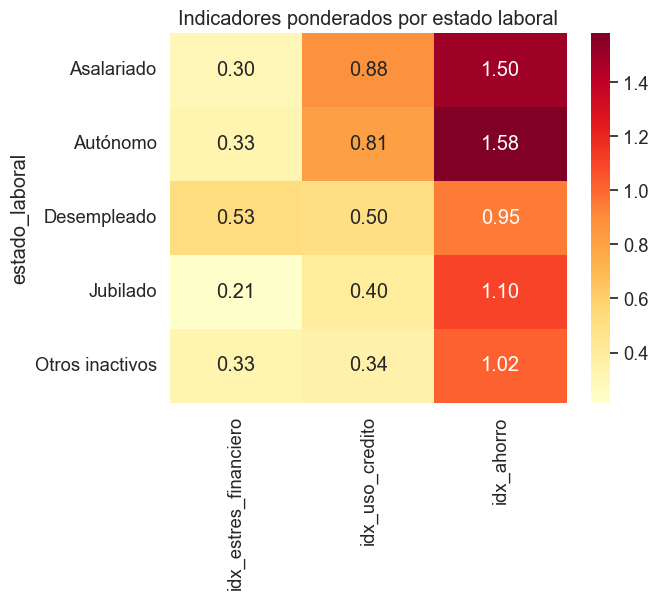

In [135]:
heat_data = pivot_laboral_w.set_index("estado_laboral")[
    ["idx_estres_financiero", "idx_uso_credito", "idx_ahorro"]
]

sns.heatmap(
    heat_data,
    annot=True,
    cmap="YlOrRd",
    fmt=".2f"
)

plt.title("Indicadores ponderados por estado laboral")
plt.show()

In [136]:
pivot_familia_w = make_weighted_pivot(work, "familia", "weight")
display(pivot_familia_w)

,familia,idx_estres_financiero,idx_uso_credito,idx_ahorro,N_muestral,N_ponderado
0,Otros adultos,0.318,0.397,1.212,1787,8.037777e+06
1,Vive con pareja,0.320,0.775,1.335,4812,2.259480e+07
2,Vive solo,0.309,0.604,1.320,955,4.416471e+06


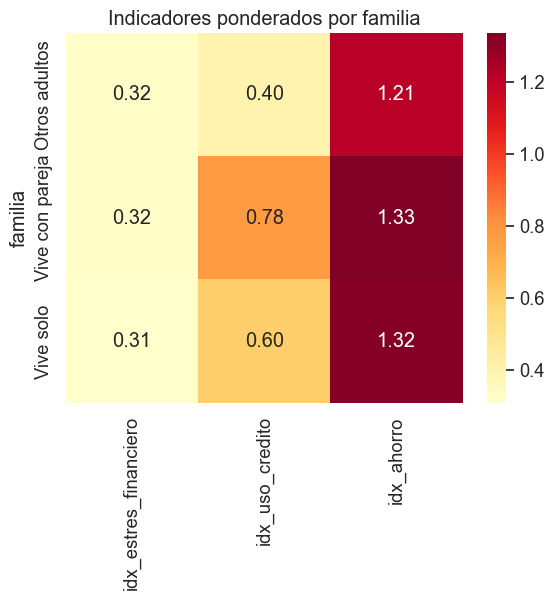

In [137]:
heat_data = pivot_familia_w.set_index("familia")[
    ["idx_estres_financiero", "idx_uso_credito", "idx_ahorro"]
]

sns.heatmap(
    heat_data,
    annot=True,
    cmap="YlOrRd",
    fmt=".2f"
)

plt.title("Indicadores ponderados por familia")
plt.show()

In [138]:
pivot_inmob_w = make_weighted_pivot(work, "riq_inmob", "weight")
display(pivot_inmob_w)

,riq_inmob,idx_estres_financiero,idx_uso_credito,idx_ahorro,N_muestral,N_ponderado
0,No posee residencia principal,0.488,0.608,1.125,1748,8.730344e+06
1,Residencia principal y otras,0.214,0.626,1.546,2847,1.221191e+07
2,Solo residencia principal,0.303,0.739,1.207,2959,1.410679e+07


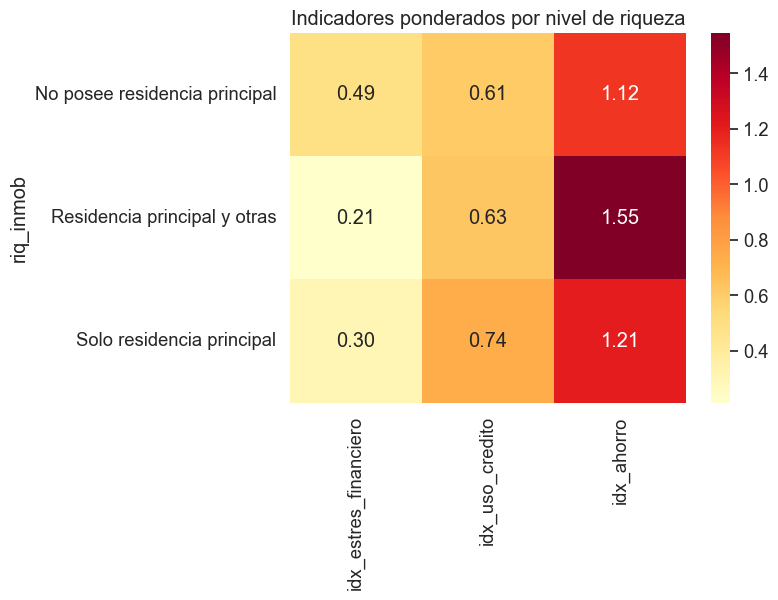

In [139]:
heat_data = pivot_inmob_w.set_index("riq_inmob")[
    ["idx_estres_financiero", "idx_uso_credito", "idx_ahorro"]
]

sns.heatmap(
    heat_data,
    annot=True,
    cmap="YlOrRd",
    fmt=".2f"
)

plt.title("Indicadores ponderados por nivel de riqueza")
plt.show()

## 4. Indicador de vulnerabilidad

- Uso de préstamos para cubrir gastos
- Morosidad
- Denegaciones de préstamos
- Uso de ahorros para cubrir gastos básicos.


Este indicador permite aproximar situaciones de tensión financiera estructural.


In [140]:
resumen_vuln = pd.DataFrame({
    "conteo": df["vulnerabilidad"].value_counts().sort_index(),
    "proporcion": df["vulnerabilidad"].value_counts(normalize=True).sort_index()
})

resumen_vuln.round(3)


,conteo,proporcion
vulnerabilidad,,
0,5780,0.765
1,1774,0.235


### 4.1 Vulnerabilidad por nivel educativo

In [141]:
vuln_edu = pd.crosstab(
    df["cat_educacion"],
    df["vulnerabilidad"],
    normalize="index"
).round(2)

vuln_edu



vulnerabilidad,0,1
cat_educacion,,
Educación Primaria,0.69,0.31
Educación Secundaria,0.75,0.25
Universidad,0.84,0.16


In [142]:
vuln_edu = pd.crosstab(
    df["cat_educacion"],
    df["vulnerabilidad"],
    values=df["weight"],
    aggfunc="sum",
    normalize="index"
).round(2)

vuln_edu


vulnerabilidad,0,1
cat_educacion,,
Educación Primaria,0.68,0.32
Educación Secundaria,0.72,0.28
Universidad,0.82,0.18


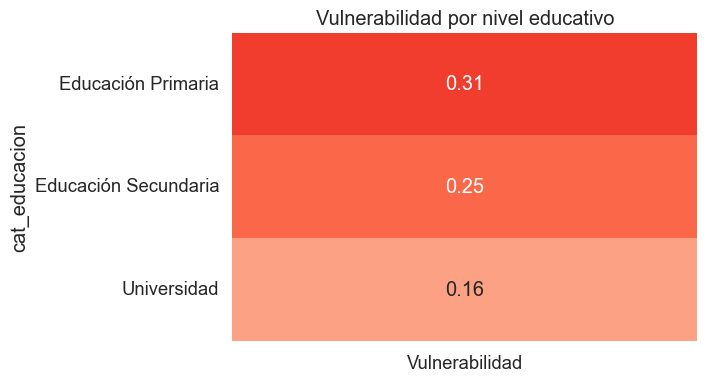

In [143]:
tabla_edu = pd.crosstab(
    df["cat_educacion"],
    df["vulnerabilidad"],
    normalize="index"
)[1]

tabla_edu = tabla_edu.to_frame(name="Vulnerabilidad")

plt.figure(figsize=(6,4))
sns.heatmap(
    tabla_edu,
    annot=True,
    cmap="Reds",
    vmin=0,
    vmax=0.5,
    cbar=False
)

plt.title("Vulnerabilidad por nivel educativo")
plt.show()



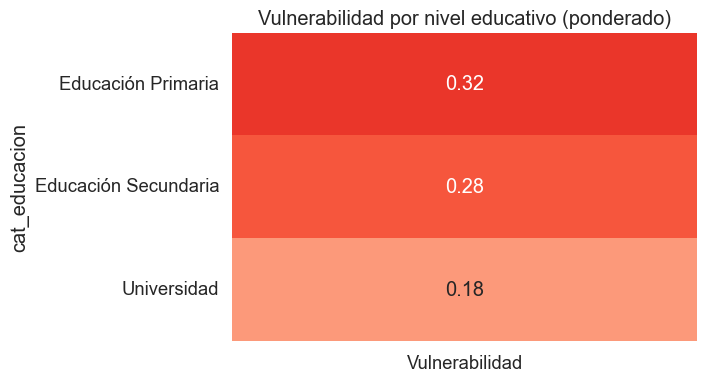

In [144]:
tabla_edu = pd.crosstab(
    df["cat_educacion"],
    df["vulnerabilidad"],
    values=df["weight"],
    aggfunc="sum",
    normalize="index"
)[1]

tabla_edu = tabla_edu.to_frame(name="Vulnerabilidad")

plt.figure(figsize=(6,4))
sns.heatmap(
    tabla_edu,
    annot=True,
    cmap="Reds",
    vmin=0,
    vmax=0.5,
    cbar=False
)

plt.title("Vulnerabilidad por nivel educativo (ponderado)")
plt.show()


### 4.2. Vulnerabilidad por situación laboral

In [145]:
pd.crosstab(
    df["estado_laboral"],
    df["vulnerabilidad"],
    values=df["weight"],
    aggfunc="sum",
    normalize="index"
).round(2)


vulnerabilidad,0,1
estado_laboral,,
Asalariado,0.76,0.24
Autónomo,0.73,0.27
Desempleado,0.59,0.41
Jubilado,0.81,0.19
Otros inactivos,0.73,0.27


In [146]:
pd.crosstab(
    df["estado_laboral"],
    df["vulnerabilidad"],
    normalize="index"
).round(2)

vulnerabilidad,0,1
estado_laboral,,
Asalariado,0.78,0.22
Autónomo,0.77,0.23
Desempleado,0.61,0.39
Jubilado,0.82,0.18
Otros inactivos,0.75,0.25


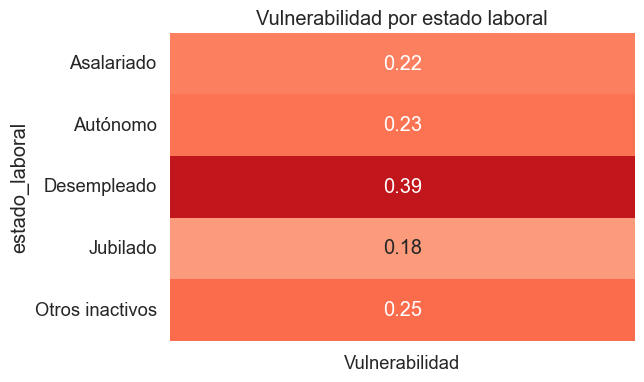

In [147]:
tabla_lab = pd.crosstab(
    df["estado_laboral"],
    df["vulnerabilidad"],
    normalize="index"
)[1]

tabla_lab = tabla_lab.to_frame(name="Vulnerabilidad")

plt.figure(figsize=(6,4))
sns.heatmap(
    tabla_lab,
    annot=True,
    cmap="Reds",
    vmin=0,
    vmax=0.5,
    cbar=False
)

plt.title("Vulnerabilidad por estado laboral")
plt.show()


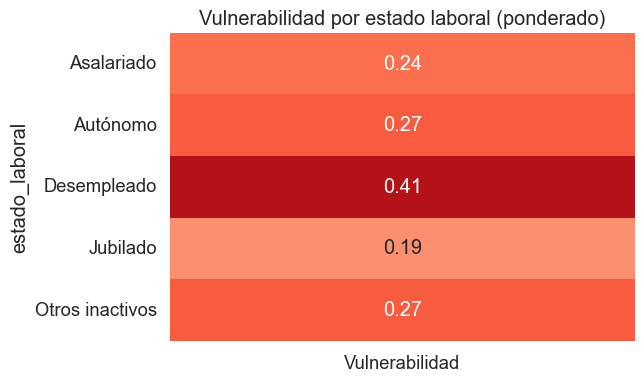

In [148]:
tabla_lab = pd.crosstab(
    df["estado_laboral"],
    df["vulnerabilidad"],
    values=df["weight"],
    aggfunc="sum",
    normalize="index"
)[1]

tabla_lab = tabla_lab.to_frame(name="Vulnerabilidad")

plt.figure(figsize=(6,4))
sns.heatmap(
    tabla_lab,
    annot=True,
    cmap="Reds",
    vmin=0,
    vmax=0.5,
    cbar=False
)

plt.title("Vulnerabilidad por estado laboral (ponderado)")
plt.show()


### 4.3. Vulnerabilidad por tipo de unidad familiar


In [149]:
pd.crosstab(
    df["familia"],
    df["vulnerabilidad"],
    values=df["weight"],
    aggfunc="sum",
    normalize="index"
).round(2)


vulnerabilidad,0,1
familia,,
Otros adultos,0.74,0.26
Vive con pareja,0.74,0.26
Vive solo,0.74,0.26


### 4.4. Vulnerabilidad por edad

In [150]:
vuln_age = pd.crosstab(
    work["edad_grupo"],
    df["vulnerabilidad"],
    normalize="index"
).round(2)

vuln_age


vulnerabilidad,0,1
edad_grupo,,
18-34 años,0.77,0.23
35-44 años,0.77,0.23
45-54 años,0.74,0.26
55-64 años,0.75,0.25
65-79 años,0.81,0.19


In [151]:
vuln_age = pd.crosstab(
    work["edad_grupo"],
    df["vulnerabilidad"],
    values=df["weight"],
    aggfunc="sum",
    normalize="index"
).round(3)

vuln_age


vulnerabilidad,0,1
edad_grupo,,
18-34 años,0.745,0.255
35-44 años,0.729,0.271
45-54 años,0.708,0.292
55-64 años,0.719,0.281
65-79 años,0.795,0.205


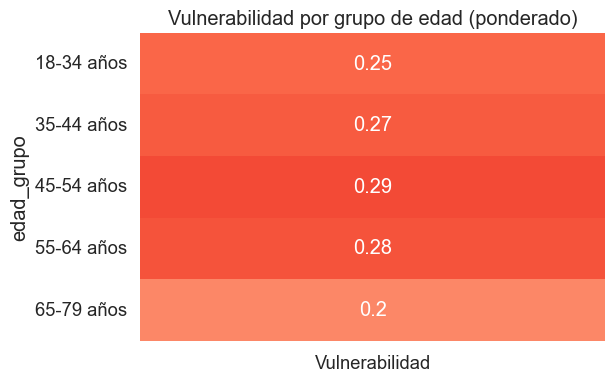

In [152]:
tabla_age = pd.crosstab(
    work["edad_grupo"],
    df["vulnerabilidad"],
    values=df["weight"],
    aggfunc="sum",
    normalize="index"
)[1]

tabla_age = tabla_age.to_frame(name="Vulnerabilidad")

plt.figure(figsize=(6,4))
sns.heatmap(
    tabla_age,
    annot=True,
    cmap="Reds",
    vmin=0,
    vmax=0.5,
    cbar=False
)

plt.title("Vulnerabilidad por grupo de edad (ponderado)")
plt.show()


### 4.5. Vulnerabilidad por Competencia financiera

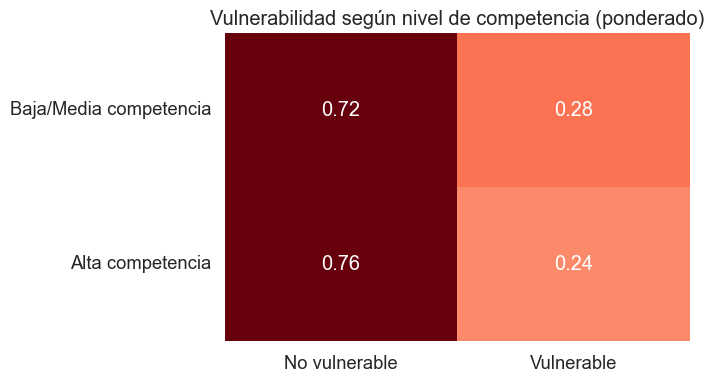

In [153]:
tabla_comp_vuln = pd.crosstab(
    df["comp_fin_bin"],
    df["vulnerabilidad"],
    values=df["weight"],
    aggfunc="sum",
    normalize="index"
)

tabla_comp_vuln.index = ["Baja/Media competencia", "Alta competencia"]
tabla_comp_vuln.columns = ["No vulnerable", "Vulnerable"]

plt.figure(figsize=(6,4))
sns.heatmap(
    tabla_comp_vuln,
    annot=True,
    cmap="Reds",
    vmin=0,
    vmax=0.6,
    cbar=False
)

plt.title("Vulnerabilidad según nivel de competencia (ponderado)")
plt.show()


### 4.6. Test estadisticos Vulnerabilidad

In [154]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model_vuln = smf.glm(
    "vulnerabilidad ~ comp_fin_bin + C(estado_laboral) + C(edad_grupo) + C(cat_educacion) + C(riq_inmob) + C(familia)",
    data=df,
    family=sm.families.Binomial(),
    freq_weights=df["weight"]
).fit(cov_type="HC3")

print(model_vuln.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:         vulnerabilidad   No. Observations:                 7554
Model:                            GLM   Df Residuals:              35049032.93
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.9032e+07
Date:                Sat, 14 Feb 2026   Deviance:                   3.8064e+07
Time:                        11:03:46   Pearson chi2:                 3.52e+07
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:                  HC3                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

In [155]:
import numpy as np

params = model_vuln.params
conf = model_vuln.conf_int()

odds = np.exp(params)
conf_odds = np.exp(conf)

results = pd.DataFrame({
    "OR": odds,
    "CI_low": conf_odds[0],
    "CI_high": conf_odds[1],
    "p_value": model_vuln.pvalues
})

results


,OR,CI_low,CI_high,p_value
Intercept,0.670957,0.669061,0.672858,0.000000e+00
C(estado_laboral)[T.Autónomo],1.124277,1.121258,1.127304,0.000000e+00
C(estado_laboral)[T.Desempleado],1.827081,1.822622,1.831550,0.000000e+00
C(estado_laboral)[T.Jubilado],0.883357,0.880083,0.886644,0.000000e+00
C(estado_laboral)[T.Otros inactivos],1.107831,1.105025,1.110644,0.000000e+00
C(edad_grupo)[T.35-44 años],1.095130,1.092179,1.098088,0.000000e+00
C(edad_grupo)[T.45-54 años],1.273047,1.269741,1.276360,0.000000e+00
C(edad_grupo)[T.55-64 años],1.171622,1.168440,1.174813,0.000000e+00
C(edad_grupo)[T.65-79 años],0.886286,0.882919,0.889667,0.000000e+00
C(cat_educacion)[T.Educación Secundaria],0.790309,0.788695,0.791925,0.000000e+00


pseudo-R²

In [156]:
llf = model_vuln.llf
llnull = model_vuln.null_deviance / -2

pseudo_r2 = 1 - (llf / llnull)
pseudo_r2


0.0539182971033324

efectos marginales

In [157]:
marg = model_vuln.get_margeff()
print(marg.summary())


         GLM Marginal Effects        
Dep. Variable:         vulnerabilidad
Method:                          dydx
At:                           overall
                                                  dy/dx    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
C(estado_laboral)[T.Autónomo]                    0.0205      0.000     85.380      0.000       0.020       0.021
C(estado_laboral)[T.Desempleado]                 0.1053      0.000    488.332      0.000       0.105       0.106
C(estado_laboral)[T.Jubilado]                   -0.0217      0.000    -65.484      0.000      -0.022      -0.021
C(estado_laboral)[T.Otros inactivos]             0.0179      0.000     79.146      0.000       0.017       0.018
C(edad_grupo)[T.35-44 años]                      0.0159      0.000     66.025      0.000       0.015       0.016
C(edad_grupo)[T.45-54 años]                      0.0422  

C:\Users\edo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\genmod\generalized_linear_model.py:2381: UserWarning: weights are not taken into account by margeff
  warnings.warn("weights are not taken into account by margeff")


AIC con e senza competencia

In [158]:
model_no_comp = smf.glm(
    "vulnerabilidad ~ C(estado_laboral) + C(edad_grupo) + C(cat_educacion) + C(riq_inmob) + C(familia)",
    data=df,
    family=sm.families.Binomial(),
    freq_weights=df["weight"]
).fit(cov_type="HC3")

model_no_comp.aic, model_vuln.aic


(38065940.905977994, 38064380.5601244)

##### Interpretación del modelo de vulnerabilidad

- La competencia financiera presenta un efecto negativo y significativo sobre la vulnerabilidad (OR = 0.968, p < 0.001).
- El efecto marginal es reducido: disminuye la probabilidad de vulnerabilidad en aproximadamente −0.6 puntos porcentuales.
- El pseudo R² del modelo es moderado (≈ 0.054), lo que indica que la vulnerabilidad depende principalmente de factores estructurales.

Factores con mayor impacto:

- Desempleo: OR = 1.83 → fuerte aumento del riesgo.
- Educación universitaria: OR = 0.46 → fuerte reducción del riesgo.
- Propiedad inmobiliaria múltiple: OR = 0.41 → importante efecto protector.

Comparación de modelos:
- El modelo con competencia mejora ligeramente el AIC respecto al modelo sin competencia.
- Sin embargo, la mejora es pequeña, lo que confirma que la competencia financiera tiene un impacto limitado frente a variables socioeconómicas.

Conclusión:
La vulnerabilidad financiera está determinada principalmente por condiciones estructurales (empleo, educación y riqueza), mientras que la competencia financiera aporta un efecto adicional pero de magnitud reducida.


## 5. Análisis de brechas estructurales y oportunidades de negocio

## Tests estadísticos – Vulnerabilidad

### 1. Modelo estimado

Se estimó una regresión logística ponderada (GLM Binomial con pesos muestrales).

Variable dependiente:
- vulnerabilidad (0/1)

Variables explicativas:
- competencia financiera (comp_fin_bin)
- estado laboral
- edad (edad_grupo)
- nivel educativo
- riqueza inmobiliaria
- tipo de hogar

---

### 2. Resultados principales

Pseudo R² ≈ 0.054  
→ El modelo explica aproximadamente el 5,4% de la variación en la vulnerabilidad.

Factores con mayor efecto:

- Desempleado → OR ≈ 1.83  
  Incrementa fuertemente la probabilidad de vulnerabilidad.

- Universidad → OR ≈ 0.46  
  Reduce significativamente la probabilidad de vulnerabilidad.

- Propietarios con varias viviendas → OR ≈ 0.41  
  Fuerte efecto protector.

- Edad 45–54 → OR ≈ 1.27  
  Mayor probabilidad relativa frente a 18–34.

---

### 3. Competencia financiera

comp_fin_bin → OR ≈ 0.97  
Efecto marginal ≈ −0.6 puntos porcentuales.

Conclusión:
La competencia financiera reduce la probabilidad de vulnerabilidad,
pero el efecto es pequeño en magnitud económica.

---

### 4. Comparación de modelos

Se comparó:

- Modelo sin competencia
- Modelo con competencia

El AIC disminuye al incluir competencia.

Conclusión:
La competencia mejora ligeramente el modelo,
pero no es un determinante principal.

---

## Conclusión general

La vulnerabilidad está principalmente asociada a:

- Desempleo
- Bajo nivel educativo
- Baja riqueza inmobiliaria

La competencia financiera influye,
pero su impacto es mucho menor que los factores estructurales.

Por tanto, la vulnerabilidad responde más a condiciones socioeconómicas
que únicamente a nivel de alfabetización financiera.


# Elección del KPI principal – Comparación técnica y operativa

## Recomendación: Vulnerabilidad (modelo logístico)

### Razones técnicas y estratégicas

1. Interpretación directa en términos de riesgo  
   El modelo logístico permite estimar cómo cambian las probabilidades de estar en situación de vulnerabilidad ante variaciones en las variables explicativas.  
   Esto facilita la interpretación en términos de aumento o reducción del riesgo.

2. Coherencia con riesgo financiero  
   La variable vulnerabilidad representa una situación crítica observable (evento de riesgo).  
   Por tanto, está más alineada con análisis de riesgo financiero y toma de decisiones estratégicas.

3. Capacidad de segmentación  
   Permite identificar claramente qué grupos presentan mayor probabilidad de vulnerabilidad, lo que facilita el diseño de políticas y estrategias de intervención.

4. Comunicabilidad  
   Resulta más sencillo comunicar probabilidades de riesgo a un público no técnico (board, decisores, stakeholders).

---

## Comparación cuantitativa

| Indicador | R² / Pseudo R² | Interpretación | Uso estratégico |
|------------|----------------|---------------|----------------|
| idx_estres | 0.052 | Variación media del índice | Descriptivo |
| vulnerabilidad | 0.054 | Probabilidad de riesgo | Estratégico |

El poder explicativo de ambos modelos es muy similar (≈ 5%).  
La diferencia principal es conceptual y operativa.

---

## Conclusión

Se propone utilizar:

- Vulnerabilidad como KPI principal.
- Índice de estrés financiero como indicador complementario descriptivo.

La vulnerabilidad permite una lectura más directa del riesgo financiero y una mejor aplicación en términos de política y estrategia.


# Pruebas estadisticas sin peso

Kruskal–Wallis 
Pq Variables son:

- Suma de estrategias binarias
- Variable discreta
- Sin distribución normal y a menudo asimétrica (0 > 1 o al reves, casi nunca son iguales)

H0: Las distribuciones de idx_estres_financiero, idx_uso_credito, idx_ahorro son las mismas en todos los grupos estado_laboral.
H1: Al menos un grupo es diferente.

In [160]:


for idx in ["idx_estres_financiero", "idx_uso_credito", "idx_ahorro"]:
    groups = [
        work.loc[work["estado_laboral"] == g, idx]
        for g in work["estado_laboral"].dropna().unique()
    ]
    stat, p = kruskal(*groups)
    print(f"{idx}: p-value = {p}")


idx_estres_financiero: p-value = 1.7984267172869473e-29
idx_uso_credito: p-value = 1.570609899051382e-138
idx_ahorro: p-value = 4.133913719725067e-92


Conclusion H1: todos los diferentes 

H0: Las distribuciones de idx_estres_financiero, idx_uso_credito, idx_ahorro son las mismas en todos los grupos de nivel educativo.
H1: Al menos un grupo es diferente.

In [161]:

for idx in ["idx_estres_financiero", "idx_uso_credito", "idx_ahorro"]:
    groups = [
        work.loc[work["cat_educacion"] == g, idx]
        for g in work["cat_educacion"].dropna().unique()
    ]
    stat, p = kruskal(*groups)
    print(f"{idx}: p-value = {p}")



idx_estres_financiero: p-value = 2.6247596562693138e-34
idx_uso_credito: p-value = 3.5937151699425405e-13
idx_ahorro: p-value = 5.538073180568106e-220


Conclusion H1: todos los diferentes 

H0: Las distribuciones de idx_estres_financiero, idx_uso_credito, idx_ahorro son las mismas en todos los grupos de estado familiar.
H1: Al menos un grupo es diferente.

In [162]:
for idx in ["idx_estres_financiero", "idx_uso_credito", "idx_ahorro"]:
    groups = [
        work.loc[work["familia"] == g, idx]
        for g in work["familia"].dropna().unique()
    ]
    stat, p = kruskal(*groups)
    print(f"{idx}: p-value = {p}")

idx_estres_financiero: p-value = 0.08352501697457403
idx_uso_credito: p-value = 2.4748763873992805e-87
idx_ahorro: p-value = 1.5737619303320957e-09


- Para idx_uso_credito y idx_ahorro todos son diferentes 
- Para idx_estres_financiero son iguales para todos grupos 

H0: Las distribuciones de idx_estres_financiero, idx_uso_credito, idx_ahorro son las mismas en todos los grupos de propiedad inmobilaria.
H1: Al menos un grupo es diferente.

In [163]:
for idx in ["idx_estres_financiero", "idx_uso_credito", "idx_ahorro"]:
    groups = [
        work.loc[work["riq_inmob"] == g, idx]
        for g in work["riq_inmob"].dropna().unique()
    ]
    stat, p = kruskal(*groups)
    print(f"{idx}: p-value = {p}")

idx_estres_financiero: p-value = 1.0316289601244228e-38
idx_uso_credito: p-value = 5.064901159357695e-19
idx_ahorro: p-value = 4.545568800234822e-51


Conclusion H1: todos los diferentes 

# Pruebas estadisticas con peso 

Modelo de regresión lineal ponderado (WLS) - La prueba estadística de Mínimos Cuadrados Ponderados (WLS, por sus siglas en inglés: Weighted Least Squares) es un método de regresión utilizado cuando los datos presentan heterocedasticidad, es decir, cuando la varianza de los residuos no es constante a lo largo de todas las observaciones. 


Categorías básicas (con que compara):
- estado_laboral → Asalariado
- edad_grupo → 18-34 años
- cat_educacion → Educación Primaria
- riq_inmob → No posee residencia principal
- familia → Otros adultos 

In [164]:
cols = ["idx_estres_financiero",'idx_ahorro','idx_uso_credito', "estado_laboral", "edad_grupo", "cat_educacion", "riq_inmob", "familia", "weight"]
work_model = work[cols].copy()

print("Rows before:", len(work_model))
work_model = work_model.dropna()
print("Rows after :", len(work_model))


Rows before: 7554
Rows after : 7554


In [165]:
work_model = work_model[work_model["weight"] > 0]

## Estres financiero

In [166]:
model = smf.wls(
    "idx_estres_financiero ~ C(estado_laboral) + C(edad_grupo) + C(cat_educacion) + C(riq_inmob) + C(familia)",
    data=work_model,
    weights=work_model["weight"]
).fit(cov_type="HC3")   # robust SE

print(model.summary())


                              WLS Regression Results                             
Dep. Variable:     idx_estres_financiero   R-squared:                       0.052
Model:                               WLS   Adj. R-squared:                  0.050
Method:                    Least Squares   F-statistic:                     17.10
Date:                   Sat, 14 Feb 2026   Prob (F-statistic):           2.36e-42
Time:                           11:03:50   Log-Likelihood:                -7921.5
No. Observations:                   7554   AIC:                         1.587e+04
Df Residuals:                       7539   BIC:                         1.598e+04
Df Model:                             14                                         
Covariance Type:                     HC3                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------

### Conclusiones de la variación del índice estres financiero

El modelo explica el 5,2% de la variación del índice. 

Desempleado → +0.175 (p < 0.001) - los desempleados tienen un índice de estrés financiero 0,175 puntos más alto, en igualdad de condiciones.

Secundaria → −0.061 (p = 0.016)
Universidad → −0.163 (p < 0.001) - Los niveles más altos de educación se asocian con un menor estrés financiero. 

Residencia principal → −0.181
Residencia + otras → −0.245  - Ser propietario de una propiedad reduce significativamente el estrés financiero. 

!Ningún grupo de edad es significativo.!

Tras controlar los factores:

- El estrés financiero es significativamente mayor entre los desempleados
- Significativamente menor entre las personas con educación superior
- Significativamente menor entre los propietarios de vivienda
- La edad por sí sola no influye

## Uso credito

In [167]:
import statsmodels.formula.api as smf

model = smf.wls(
    "idx_uso_credito ~ C(estado_laboral) + C(edad_grupo) + C(cat_educacion) + C(riq_inmob) + C(familia)",
    data=work_model,
    weights=work_model["weight"]
).fit(cov_type="HC3")   # robust SE

print(model.summary())

                            WLS Regression Results                            
Dep. Variable:        idx_uso_credito   R-squared:                       0.130
Model:                            WLS   Adj. R-squared:                  0.129
Method:                 Least Squares   F-statistic:                     71.13
Date:                Sat, 14 Feb 2026   Prob (F-statistic):          8.25e-191
Time:                        11:03:50   Log-Likelihood:                -9774.8
No. Observations:                7554   AIC:                         1.958e+04
Df Residuals:                    7539   BIC:                         1.968e+04
Df Model:                          14                                         
Covariance Type:                  HC3                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

### Conclusiones de la variación del índice uso credito

El modelo explica el 13% de la variación en la utilización del crédito. Es más probable que los factores sociodemográficos expliquen el uso del crédito que el estrés. 

Desempleado → −0.297 (p < 0.001)
Jubilado → −0.183
Otros inactivos → −0.330 - Los desempleados e inactivos utilizan el crédito con mucha menos frecuencia. 

35–44 → +0.306
45–54 → +0.228
65–79 → −0.206 - La actividad crediticia alcanza su punto máximo entre los 35 y los 44 años.
Después de los 65, se produce un marcado descenso. 

Secundaria → +0.088 (significativo)
Universidad → no significativo - La educación superior no aumenta la actividad crediticia, pero la educación secundaria sí la aumenta ligeramente. 

Residencia principal → +0.166
Residencia + otras → +0.105 - Los propietarios tienen más probabilidades de utilizar crédito (Al menos hipotecas)

Vive con pareja → +0.279
Vive solo → +0.182 - Los hogares con pareja tienen mayor probabilidad de utilizar crédito. 

- El uso de credito es significativamente menor entre los desempleados e inactivos
- Significativamente mayor entre las personas con edad de 35 hasta 54
- Significativamente mayor entre las personas con educación secundaria

## Ahorro 

In [168]:
model = smf.wls(
    "idx_ahorro ~ C(estado_laboral) + C(edad_grupo) + C(cat_educacion) + C(riq_inmob) + C(familia)",
    data=work_model,
    weights=work_model["weight"]
).fit(cov_type="HC3")   # robust SE

print(model.summary())

                            WLS Regression Results                            
Dep. Variable:             idx_ahorro   R-squared:                       0.199
Model:                            WLS   Adj. R-squared:                  0.197
Method:                 Least Squares   F-statistic:                     104.3
Date:                Sat, 14 Feb 2026   Prob (F-statistic):          8.23e-277
Time:                        11:03:50   Log-Likelihood:                -10688.
No. Observations:                7554   AIC:                         2.141e+04
Df Residuals:                    7539   BIC:                         2.151e+04
Df Model:                          14                                         
Covariance Type:                  HC3                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

### Conclusiones de la variación del índice ahorro


El modelo explica casi el 20% de la variación en el comportamiento del ahorro. Los ahorros están mucho más fuertemente estructurados por factores sociodemográficos. 

Autónomos → +0,119 (p=0,005) - Los autónomos utilizan más instrumentos de ahorro.

Desempleados → -0,346 (efecto muy fuerte) - Los desempleados participan significativamente menos en la actividad de ahorro.

Jubilado → -0,192
Inactivos → -0,295 - Los grupos inactivos ahorran significativamente menos.

18–34 es la categoría base y tiene el nivel de índice más alto.
Todos los grupos de edad (en comparación con el grupo de 18 a 34 años) tienen una tasa de ahorro más baja.
!hay que comprobar que pasa aquí!

Secundaria → +0.421
Universidad → +0.713 - La educación superior aumenta el índice en 0,71 puntos. 

Residencia principal y otras → +0.451
Solo residencia principal → +0.164 - La propiedad y el ahorro están estrechamente relacionados. 

Vive con pareja → +0.150
Vive solo → +0.192 - Aquellos que viven solos son incluso un poco más activos a la hora de ahorrar. 



## Conclusiones relevantes para responder a pregunta del negocio

El comportamiento de ahorro es el componente más estructurado por factores socio-demográficos, especialmente nivel educativo y patrimonio inmobiliario.
Por tanto, una estrategia de segmentación para productos de ahorro resulta coherente con las tendencias nacionales observadas. 

El uso del crédito responde principalmente al ciclo de vida y a la situación laboral.
La oferta crediticia debería adaptarse a perfiles económicamente activos y con estabilidad laboral.

El estrés financiero está fuertemente asociado al desempleo y a la baja inclusión financiera.
Antes de ofrecer productos financieros complejos, puede ser recomendable implementar programas de educación y acompañamiento financiero para estos segmentos. (Comprobar si hay correlacion entre alfabetizacion fin. y comportamiento)